# Full-Resolution MNIST-10 Hybrid Conv + DenseAM Sweep

This notebook is the full `28 x 28`, all-digit version of the hybrid latent free-energy experiment. The earlier `0/1` setting worked with `K=128`, but that gives only about 12-13 global prototypes per digit on MNIST-10. This notebook uses class-balanced prototype initialization and larger `K` values.

Main changes relative to the 0/1 notebook:

- full `28 x 28` images;
- all digits `0..9`;
- class-balanced training/validation subsets;
- class-balanced random and per-class MiniBatchKMeans prototype initialization;
- larger prototype counts, e.g. `K=500, 1000, 1500`;
- wider conv feature bank;
- diagnostics for class coverage, class entropy, duplicate/collapse, and sample-to-prototype distance.

In [1]:
import math
import time
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax, random
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans

jax.config.update("jax_enable_x64", False)

print("JAX version:", jax.__version__)
print("Devices:", jax.devices())
print("Default backend:", jax.default_backend())

JAX version: 0.4.33
Devices: [CudaDevice(id=0)]
Default backend: gpu


## Configuration

Quick mode is still a real GPU sweep, but not a paper-quality run. The goal is to find the right scale of `K`, `lambda`, and conv width for full MNIST-10. Set `RESEARCH_MODE = True` to expand the budget.

In [2]:
SEED = 0
RESEARCH_MODE = False

IMG_SIDE = 28
DIGITS = tuple(range(10))
N_CLASSES = len(DIGITS)

def cfg(K, lam, init, hidden_ch=64, kernel=5, lr=6.0e-4, train_dense=True, W_scale=0.035):
    return {
        "K": K,
        "lambda": lam,
        "init": init,
        "hidden_ch": hidden_ch,
        "kernel": kernel,
        "lr": lr,
        "train_dense": train_dense,
        "W_scale": W_scale,
    }

if RESEARCH_MODE:
    TRAIN_PER_CLASS = 2000
    VALID_PER_CLASS = 400
    N_TIME_SWEEP = 8
    STEPS_PER_TIME_SWEEP = 450
    N_TIME_FINAL = 12
    STEPS_PER_TIME_FINAL = 1800
    BATCH_SIZE = 128
    N_REVERSE_STEPS = 520
    N_SAMPLES = 100
    SEARCH_CONFIGS = []
    for K in [500, 1000, 1500, 2000]:
        for init in ["balanced_random", "balanced_kmeans"]:
            for lam in [0.20, 0.30, 0.40, 0.55, 0.70]:
                SEARCH_CONFIGS.append(cfg(K, lam, init, lr=5.0e-4 if K >= 1500 else 6.0e-4, train_dense=True))
    for K in [1000, 1500, 2000]:
        for init in ["balanced_random", "balanced_kmeans"]:
            for lam in [0.30, 0.45, 0.60]:
                SEARCH_CONFIGS.append(cfg(K, lam, init, lr=5.0e-4, train_dense=False))
    SEARCH_CONFIGS += [
        cfg(1000, 0.35, "balanced_kmeans", hidden_ch=96, kernel=5, lr=4.0e-4),
        cfg(1000, 0.50, "balanced_kmeans", hidden_ch=96, kernel=7, lr=4.0e-4),
        cfg(1500, 0.35, "balanced_random", hidden_ch=96, kernel=5, lr=4.0e-4),
        cfg(1500, 0.50, "balanced_kmeans", hidden_ch=96, kernel=5, lr=4.0e-4),
        cfg(2000, 0.35, "balanced_random", hidden_ch=96, kernel=5, lr=3.5e-4),
    ]
else:
    TRAIN_PER_CLASS = 1000
    VALID_PER_CLASS = 200
    N_TIME_SWEEP = 7
    STEPS_PER_TIME_SWEEP = 220
    N_TIME_FINAL = 10
    STEPS_PER_TIME_FINAL = 900
    BATCH_SIZE = 96
    N_REVERSE_STEPS = 420
    N_SAMPLES = 100
    SEARCH_CONFIGS = []
    for K in [500, 1000, 1500]:
        for init in ["balanced_random", "balanced_kmeans"]:
            for lam in ([0.25, 0.35, 0.50, 0.65] if K < 1500 else [0.20, 0.30, 0.45, 0.60]):
                SEARCH_CONFIGS.append(cfg(K, lam, init, lr=5.0e-4 if K >= 1000 else 6.0e-4, train_dense=True))
    for K in [500, 1000, 1500]:
        for init in ["balanced_random", "balanced_kmeans"]:
            for lam in [0.35, 0.50, 0.65]:
                SEARCH_CONFIGS.append(cfg(K, lam, init, lr=5.0e-4, train_dense=False))
    SEARCH_CONFIGS += [
        cfg(1000, 0.35, "balanced_random", hidden_ch=96, kernel=5, lr=4.0e-4),
        cfg(1000, 0.50, "balanced_random", hidden_ch=96, kernel=5, lr=4.0e-4),
        cfg(1000, 0.35, "balanced_kmeans", hidden_ch=96, kernel=5, lr=4.0e-4),
        cfg(1000, 0.50, "balanced_kmeans", hidden_ch=96, kernel=7, lr=4.0e-4),
        cfg(1500, 0.30, "balanced_random", hidden_ch=96, kernel=5, lr=3.5e-4),
        cfg(1500, 0.45, "balanced_kmeans", hidden_ch=96, kernel=5, lr=3.5e-4),
    ]

kBT = 1.0
TAU = 3.0
T_MIN = 8e-2
TIME_GRID_SWEEP = jnp.linspace(T_MIN, TAU, N_TIME_SWEEP)
TIME_GRID_FINAL = jnp.linspace(T_MIN, TAU, N_TIME_FINAL)

HIDDEN_BIAS_SCALE = -1.25
VISIBLE_BIAS_SCALE = 0.0
GRAD_CLIP = 10.0
REG_SCALE = 1e-6
PROTO_REG_SCALE = 1e-6
DENSE_BIAS_REG_SCALE = 1e-5

key = random.PRNGKey(SEED)
print(f"full MNIST-10 sweep configs: {len(SEARCH_CONFIGS)}")
for c in SEARCH_CONFIGS:
    print(c)

full MNIST-10 sweep configs: 48
{'K': 500, 'lambda': 0.25, 'init': 'balanced_random', 'hidden_ch': 64, 'kernel': 5, 'lr': 0.0006, 'train_dense': True, 'W_scale': 0.035}
{'K': 500, 'lambda': 0.35, 'init': 'balanced_random', 'hidden_ch': 64, 'kernel': 5, 'lr': 0.0006, 'train_dense': True, 'W_scale': 0.035}
{'K': 500, 'lambda': 0.5, 'init': 'balanced_random', 'hidden_ch': 64, 'kernel': 5, 'lr': 0.0006, 'train_dense': True, 'W_scale': 0.035}
{'K': 500, 'lambda': 0.65, 'init': 'balanced_random', 'hidden_ch': 64, 'kernel': 5, 'lr': 0.0006, 'train_dense': True, 'W_scale': 0.035}
{'K': 500, 'lambda': 0.25, 'init': 'balanced_kmeans', 'hidden_ch': 64, 'kernel': 5, 'lr': 0.0006, 'train_dense': True, 'W_scale': 0.035}
{'K': 500, 'lambda': 0.35, 'init': 'balanced_kmeans', 'hidden_ch': 64, 'kernel': 5, 'lr': 0.0006, 'train_dense': True, 'W_scale': 0.035}
{'K': 500, 'lambda': 0.5, 'init': 'balanced_kmeans', 'hidden_ch': 64, 'kernel': 5, 'lr': 0.0006, 'train_dense': True, 'W_scale': 0.035}
{'K': 500, 

2026-05-22 23:13:29.999640: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [3]:
def tree_zeros_like(tree):
    return jax.tree_util.tree_map(jnp.zeros_like, tree)


def tree_sqnorm(tree):
    leaves = jax.tree_util.tree_leaves(tree)
    if not leaves:
        return jnp.array(0.0)
    return sum(jnp.sum(jnp.square(x)) for x in leaves)


def tree_l2norm(tree):
    return jnp.sqrt(tree_sqnorm(tree) + 1e-12)


def clip_tree(tree, max_norm):
    norm = tree_l2norm(tree)
    scale = jnp.minimum(1.0, max_norm / (norm + 1e-12))
    return jax.tree_util.tree_map(lambda x: x * scale, tree)


def adam_init(params):
    return {"m": tree_zeros_like(params), "v": tree_zeros_like(params), "t": jnp.array(0, dtype=jnp.int32)}


def adam_step(params, state, grads, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    t = state["t"] + 1
    m = jax.tree_util.tree_map(lambda m, g: beta1 * m + (1.0 - beta1) * g, state["m"], grads)
    v = jax.tree_util.tree_map(lambda v, g: beta2 * v + (1.0 - beta2) * jnp.square(g), state["v"], grads)
    m_hat = jax.tree_util.tree_map(lambda x: x / (1.0 - beta1 ** t), m)
    v_hat = jax.tree_util.tree_map(lambda x: x / (1.0 - beta2 ** t), v)
    params = jax.tree_util.tree_map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps), params, m_hat, v_hat)
    return params, {"m": m, "v": v, "t": t}

## Balanced Full-Resolution MNIST

In [4]:
def _load_mnist_raw():
    from tensorflow.keras.datasets import mnist
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    return np.asarray(x_train, dtype=np.uint8), np.asarray(y_train, dtype=np.int32), np.asarray(x_test, dtype=np.uint8), np.asarray(y_test, dtype=np.int32)


def prep_balanced_mnist(x_raw, y_raw, digits, per_class, out_side, seed):
    rng = np.random.default_rng(seed)
    xs, ys = [], []
    for d in digits:
        idx_all = np.flatnonzero(y_raw == d)
        idx = rng.choice(idx_all, size=per_class, replace=False)
        xs.append(x_raw[idx])
        ys.append(y_raw[idx])
    x = np.concatenate(xs, axis=0)
    y = np.concatenate(ys, axis=0)
    perm = rng.permutation(x.shape[0])
    x, y = x[perm], y[perm]
    if out_side != 28:
        k = 28 // out_side
        cropped_side = out_side * k
        pad = (28 - cropped_side) // 2
        x = x[:, pad:pad + cropped_side, pad:pad + cropped_side]
        if k > 1:
            x = x.reshape(-1, out_side, k, out_side, k).mean(axis=(2, 4))
    x = x.astype(np.float32) / 255.0
    x = 2.0 * x - 1.0
    return jnp.asarray(x[..., None]), jnp.asarray(y)


x_train_raw, y_train_raw, x_test_raw, y_test_raw = _load_mnist_raw()
train_images, train_labels = prep_balanced_mnist(x_train_raw, y_train_raw, DIGITS, TRAIN_PER_CLASS, IMG_SIDE, SEED)
valid_images, valid_labels = prep_balanced_mnist(x_test_raw, y_test_raw, DIGITS, VALID_PER_CLASS, IMG_SIDE, SEED + 1)
print("train_images:", train_images.shape, train_images.dtype)
print("valid_images:", valid_images.shape, valid_images.dtype)
print("train class counts:", {int(d): int(jnp.sum(train_labels == d)) for d in DIGITS})

2026-05-22 23:13:30.249289: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779491610.260384  165877 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779491610.263906  165877 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


train_images: (10000, 28, 28, 1) float32
valid_images: (2000, 28, 28, 1) float32
train class counts: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}


In [5]:
def ou_coeffs(t, kBT_val=1.0):
    a = jnp.exp(-t)
    sigma2 = kBT_val * (1.0 - a * a)
    return a, jnp.maximum(sigma2, 1e-6)


def corrupt_ou(key, x0, t, kBT_val=1.0):
    eps = random.normal(key, x0.shape)
    a, sigma2 = ou_coeffs(t, kBT_val)
    xt = a * x0 + jnp.sqrt(sigma2) * eps
    target = -kBT_val * (xt - a * x0) / sigma2
    return xt, target

## Class-Balanced Prototype Initializers

`K` is split evenly across classes. This matters: all-digit MNIST with global prototypes is very sensitive to class imbalance and underallocation of prototypes per digit.

In [6]:
def class_balanced_prototypes(data, labels, K, init_kind, seed):
    if K % N_CLASSES != 0:
        raise ValueError(f"K must be divisible by {N_CLASSES}; got {K}")
    per_class = K // N_CLASSES
    rng = np.random.default_rng(seed)
    x_np = np.asarray(data).reshape((data.shape[0], -1)).astype(np.float32)
    y_np = np.asarray(labels)
    centers = []
    for d in DIGITS:
        xd = x_np[y_np == d]
        if init_kind == "balanced_random":
            idx = rng.choice(xd.shape[0], size=per_class, replace=False)
            cd = xd[idx] + 0.01 * rng.standard_normal((per_class, xd.shape[1])).astype(np.float32)
        elif init_kind == "balanced_kmeans":
            km = MiniBatchKMeans(
                n_clusters=per_class,
                batch_size=min(512, max(128, xd.shape[0])),
                n_init=3,
                max_iter=80,
                random_state=seed + int(d),
            )
            cd = km.fit(xd).cluster_centers_.astype(np.float32)
        else:
            raise ValueError(init_kind)
        centers.append(cd)
    centers = np.concatenate(centers, axis=0)
    return centers


proto_cache = {}
for cfg in SEARCH_CONFIGS:
    key_cache = (cfg["init"], cfg["K"])
    if key_cache not in proto_cache:
        print("building prototypes", key_cache)
        proto_cache[key_cache] = class_balanced_prototypes(train_images, train_labels, cfg["K"], cfg["init"], SEED + cfg["K"])
        print("  shape", proto_cache[key_cache].shape)

building prototypes ('balanced_random', 500)
  shape (500, 784)
building prototypes ('balanced_kmeans', 500)


  shape (500, 784)
building prototypes ('balanced_random', 1000)
  shape (1000, 784)
building prototypes ('balanced_kmeans', 1000)


  shape (1000, 784)
building prototypes ('balanced_random', 1500)
  shape (1500, 784)
building prototypes ('balanced_kmeans', 1500)


  shape (1500, 784)


## Hybrid Model

In [7]:
def conv_encoder(x, W):
    return lax.conv_general_dilated(x, W, window_strides=(1, 1), padding="SAME", dimension_numbers=("NHWC", "HWIO", "NHWC"))


def conv_transpose_tied(q, W):
    return lax.conv_transpose(q, W, strides=(1, 1), padding="SAME", dimension_numbers=("NHWC", "HWIO", "NHWC"), transpose_kernel=True)


def init_params(key, image_shape, prototypes, hidden_ch, kernel, W_scale):
    kW, ka = random.split(key)
    H, W_img, C = image_shape
    return {
        "base": {"b": VISIBLE_BIAS_SCALE + jnp.zeros((1, H, W_img, C), dtype=jnp.float32)},
        "conv": {
            "W": W_scale * random.normal(kW, (kernel, kernel, C, hidden_ch)),
            "a": HIDDEN_BIAS_SCALE + 0.01 * random.normal(ka, (hidden_ch,)),
        },
        "dense": {"c": jnp.asarray(prototypes), "bias": jnp.zeros((prototypes.shape[0],), dtype=jnp.float32)},
    }


def conv_hidden(params, x):
    z = conv_encoder(x, params["conv"]["W"]) + params["conv"]["a"][None, None, None, :]
    return z, jax.nn.sigmoid(z)


def conv_score(params, x):
    _, q = conv_hidden(params, x)
    return conv_transpose_tied(q, params["conv"]["W"])


def dense_logits(params, x, a_t, sigma2):
    x_flat = x.reshape((x.shape[0], -1))
    c = params["dense"]["c"]
    norm = 0.5 * (a_t ** 2) * jnp.sum(c * c, axis=1)
    dot = a_t * (x_flat @ c.T)
    return (dot - norm) / sigma2 + params["dense"]["bias"]


def dense_resp(params, x, a_t, sigma2):
    return jax.nn.softmax(dense_logits(params, x, a_t, sigma2), axis=-1)


def dense_score(params, x, a_t, sigma2, lam):
    r = dense_resp(params, x, a_t, sigma2)
    pull = r @ params["dense"]["c"]
    return lam * a_t * pull.reshape(x.shape) / sigma2


def model_score(params, x, a_t, sigma2, lam):
    return -x / sigma2 + params["base"]["b"] + conv_score(params, x) + dense_score(params, x, a_t, sigma2, lam)


def log_unnormalized(params, x, a_t, sigma2, lam):
    z, _ = conv_hidden(params, x)
    quad = -0.5 * jnp.sum(x * x, axis=(1, 2, 3)) / sigma2
    visible = jnp.sum(params["base"]["b"] * x, axis=(1, 2, 3))
    hidden = jnp.sum(jax.nn.softplus(z), axis=(1, 2, 3))
    dense = lam * logsumexp(dense_logits(params, x, a_t, sigma2), axis=1)
    return quad + visible + hidden + dense

## Conservative Score Check

In [8]:
def score_autodiff(params, x_batch, a_t, sigma2, lam):
    def logp_single(x_single):
        return log_unnormalized(params, x_single[None, ...], a_t, sigma2, lam)[0]
    return jax.vmap(jax.grad(logp_single))(x_batch)


key, k_check = random.split(key)
cfg_check = SEARCH_CONFIGS[0]
p_check = init_params(k_check, train_images.shape[1:], proto_cache[(cfg_check["init"], cfg_check["K"])], cfg_check["hidden_ch"], cfg_check["kernel"], 0.02)
for t_test in [0.08, 0.5, 1.5, 3.0]:
    a_t, sigma2 = ou_coeffs(jnp.asarray(t_test), kBT)
    x_check = train_images[:2]
    analytic = model_score(p_check, x_check, a_t, sigma2, lam=0.7)
    autodiff = score_autodiff(p_check, x_check, a_t, sigma2, lam=0.7)
    err = float(jnp.max(jnp.abs(analytic - autodiff)))
    print(f"t={t_test:.3f} sigma2={float(sigma2):.4f} max score error={err:.3e}")

t=0.080 sigma2=0.1479 max score error=1.907e-06
t=0.500 sigma2=0.6321 max score error=2.384e-07
t=1.500 sigma2=0.9502 max score error=2.384e-07
t=3.000 sigma2=0.9975 max score error=2.384e-07


## Training

In [9]:
def dsm_loss(params, key, data, t, batch_size, lam):
    k_idx, k_noise = random.split(key)
    idx = random.randint(k_idx, (batch_size,), minval=0, maxval=data.shape[0])
    x0 = data[idx]
    xt, target = corrupt_ou(k_noise, x0, t, kBT)
    a_t, sigma2 = ou_coeffs(t, kBT)
    pred = model_score(params, xt, a_t, sigma2, lam)
    mse = 0.5 * jnp.mean(jnp.sum((pred - target) ** 2, axis=(1, 2, 3)))
    reg = (
        REG_SCALE * (tree_sqnorm(params["base"]) + tree_sqnorm(params["conv"]))
        + PROTO_REG_SCALE * jnp.sum(params["dense"]["c"] ** 2)
        + DENSE_BIAS_REG_SCALE * jnp.sum(params["dense"]["bias"] ** 2)
    )
    return mse + reg


def maybe_freeze_dense_grads(grads, train_dense):
    if train_dense:
        return grads
    frozen_dense = jax.tree_util.tree_map(jnp.zeros_like, grads["dense"])
    return {"base": grads["base"], "conv": grads["conv"], "dense": frozen_dense}


@partial(jax.jit, static_argnames=("batch_size", "steps", "train_dense"))
def _train_slice_scan(params, opt_state, key, data, t, batch_size, steps, lr, lam, train_dense):
    def body(carry, _):
        params, opt_state, key = carry
        key, sub = random.split(key)
        loss_val, grads = jax.value_and_grad(dsm_loss)(params, sub, data, t, batch_size, lam)
        grads = maybe_freeze_dense_grads(grads, train_dense)
        grads = clip_tree(grads, GRAD_CLIP)
        params, opt_state = adam_step(params, opt_state, grads, lr=lr)
        return (params, opt_state, key), loss_val
    (params, opt_state, key), losses = lax.scan(body, (params, opt_state, key), xs=None, length=steps)
    return params, opt_state, key, losses


def train_schedule(key, data, cfg, t_grid, steps_per_time, batch_size, verbose=False):
    key, k_init = random.split(key)
    params = init_params(k_init, data.shape[1:], proto_cache[(cfg["init"], cfg["K"])], cfg["hidden_ch"], cfg["kernel"], W_scale=cfg.get("W_scale", 0.035))
    params_by_idx = [None for _ in range(len(t_grid))]
    losses_by_idx = [None for _ in range(len(t_grid))]
    wall0 = time.time()
    for idx in range(len(t_grid) - 1, -1, -1):
        opt_state = adam_init(params)
        t = t_grid[idx]
        params, opt_state, key, losses = _train_slice_scan(params, opt_state, key, data, t, batch_size, steps_per_time, cfg["lr"], cfg["lambda"], cfg.get("train_dense", True))
        params_by_idx[idx] = params
        losses_by_idx[idx] = np.asarray(jax.device_get(losses))
        if verbose:
            _, sigma2 = ou_coeffs(t, kBT)
            dense_mode = "trainDense" if cfg.get("train_dense", True) else "frozenDense"
            print(f"K={cfg['K']} l={cfg['lambda']} h={cfg['hidden_ch']} k={cfg['kernel']} {cfg['init']} {dense_mode} | t={float(t):.3f} sigma2={float(sigma2):.4f} loss={float(losses[-1]):.4e}")
    return params_by_idx, losses_by_idx, time.time() - wall0, key

## Evaluation And Sampling

In [10]:
def stack_params(params_seq):
    return {
        "base": {"b": jnp.stack([p["base"]["b"] for p in params_seq], axis=0)},
        "conv": {"W": jnp.stack([p["conv"]["W"] for p in params_seq], axis=0), "a": jnp.stack([p["conv"]["a"] for p in params_seq], axis=0)},
        "dense": {"c": jnp.stack([p["dense"]["c"] for p in params_seq], axis=0), "bias": jnp.stack([p["dense"]["bias"] for p in params_seq], axis=0)},
    }


def params_at(stacked, idx):
    return {
        "base": {"b": stacked["base"]["b"][idx]},
        "conv": {"W": stacked["conv"]["W"][idx], "a": stacked["conv"]["a"][idx]},
        "dense": {"c": stacked["dense"]["c"][idx], "bias": stacked["dense"]["bias"][idx]},
    }


@partial(jax.jit, static_argnames=("batch_size",))
def validation_loss(stacked, key, data, t_grid, batch_size, lam):
    time_indices = jnp.arange(t_grid.shape[0], dtype=jnp.int32)
    def one_time(carry, t_idx):
        key = carry
        key, k_idx, k_noise = random.split(key, 3)
        idx = random.randint(k_idx, (batch_size,), minval=0, maxval=data.shape[0])
        x0 = data[idx]
        t = t_grid[t_idx]
        xt, target = corrupt_ou(k_noise, x0, t, kBT)
        a_t, sigma2 = ou_coeffs(t, kBT)
        params = params_at(stacked, t_idx)
        pred = model_score(params, xt, a_t, sigma2, lam)
        loss = 0.5 * jnp.mean(jnp.sum((pred - target) ** 2, axis=(1, 2, 3)))
        return key, loss
    _, losses = lax.scan(one_time, key, time_indices)
    return jnp.mean(losses)


def build_reverse_schedule(n_steps, t_grid, tau, t_min, kBT_val):
    dt = tau / n_steps
    ss = jnp.maximum(t_min, tau - jnp.arange(n_steps) * dt)
    a_s, sigma2_s = ou_coeffs(ss, kBT_val)
    idx = jnp.argmin(jnp.abs(ss[:, None] - t_grid[None, :]), axis=1).astype(jnp.int32)
    return dt, a_s, sigma2_s, idx


@partial(jax.jit, static_argnames=("n_samples", "n_steps", "clip_x", "sampler", "final_denoise"))
def reverse_sample(key, stacked, t_grid, lam, n_samples, n_steps, tau=TAU, t_min=T_MIN, kBT_val=kBT, clip_x=2.0, sampler="sde", final_denoise=True):
    key, k_init = random.split(key)
    image_shape = stacked["base"]["b"].shape[2:]
    x = jnp.sqrt(kBT_val) * random.normal(k_init, (n_samples,) + image_shape)
    dt, a_s, sigma2_s, idx_s = build_reverse_schedule(n_steps, t_grid, tau, t_min, kBT_val)
    def body(carry, step_inputs):
        x, key = carry
        a_t, sigma2, idx = step_inputs
        params = params_at(stacked, idx)
        score = model_score(params, x, a_t, sigma2, lam)
        key, k_noise = random.split(key)
        if sampler == "sde":
            x = x + (x + 2.0 * score) * dt + jnp.sqrt(2.0 * kBT_val * dt) * random.normal(k_noise, x.shape)
        else:
            x = x + (x + score) * dt
        x = jnp.clip(x, -clip_x, clip_x)
        return (x, key), x
    (x_final, key), _ = lax.scan(body, (x, key), (a_s, sigma2_s, idx_s))
    if final_denoise:
        a_min, sigma2_min = ou_coeffs(t_min, kBT_val)
        params_min = params_at(stacked, jnp.array(0, dtype=jnp.int32))
        score_min = model_score(params_min, x_final, a_min, sigma2_min, lam)
        x_final = (x_final + sigma2_min * score_min) / jnp.maximum(a_min, 1e-6)
        x_final = jnp.clip(x_final, -1.0, 1.0)
    return x_final, key

In [11]:
def flatten_images(x):
    return np.asarray(x).reshape((x.shape[0], -1))


def pairwise_l2(a, b, block=256):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    out = np.empty((a.shape[0], b.shape[0]), dtype=np.float32)
    bn = np.sum(b * b, axis=1)
    for i in range(0, a.shape[0], block):
        ai = a[i:i + block]
        an = np.sum(ai * ai, axis=1, keepdims=True)
        d2 = an + bn[None, :] - 2.0 * ai @ b.T
        out[i:i + block] = np.sqrt(np.maximum(d2, 0.0))
    return out


def diagnostics(samples, train_x, train_y, prototypes_flat=None):
    s = flatten_images(samples)
    tr = flatten_images(train_x)
    d_st = pairwise_l2(s, tr)
    nn_idx = d_st.argmin(axis=1)
    pred = np.asarray(train_y)[nn_idx]
    control_n = min(1000, tr.shape[0])
    tr_control = tr[:control_n]
    d_tt = pairwise_l2(tr_control, tr_control)
    np.fill_diagonal(d_tt, np.inf)
    d_ss = pairwise_l2(s, s)
    np.fill_diagonal(d_ss, np.inf)
    counts = np.bincount(pred, minlength=10)
    probs = counts / max(1, counts.sum())
    uniform = np.ones(10) / 10.0
    kl = float(np.sum(np.where(probs > 0, probs * np.log(probs / uniform), 0.0)))
    out = {
        "median_sample_to_train": float(np.median(d_st.min(axis=1))),
        "median_train_to_train": float(np.median(d_tt.min(axis=1))),
        "median_sample_to_sample": float(np.median(d_ss.min(axis=1))),
        "counts": {int(i): int(c) for i, c in enumerate(counts)},
        "coverage": int(np.sum(counts > 0)),
        "class_kl": kl,
    }
    if prototypes_flat is not None:
        out["median_sample_to_proto"] = float(np.median(pairwise_l2(s, prototypes_flat).min(axis=1)))
    return out


def show_image_grid(arr, title, n_show=100, n_cols=10, vmin=-1, vmax=1):
    arr = np.asarray(arr)
    n = min(n_show, arr.shape[0])
    n_rows = math.ceil(n / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(0.75 * n_cols, 0.75 * n_rows))
    axes = np.atleast_2d(axes)
    for i, ax in enumerate(axes.ravel()):
        if i < n:
            ax.imshow(arr[i, :, :, 0], cmap="gray", vmin=vmin, vmax=vmax)
        ax.axis("off")
    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

## Sweep

In [12]:
sweep_results = []
for i, cfg in enumerate(SEARCH_CONFIGS, 1):
    print(f"\n=== full MNIST sweep {i}/{len(SEARCH_CONFIGS)}: {cfg} ===")
    key, sub = random.split(key)
    params_seq, losses, wall, key = train_schedule(sub, train_images, cfg, TIME_GRID_SWEEP, STEPS_PER_TIME_SWEEP, BATCH_SIZE, verbose=False)
    stacked = stack_params(params_seq)
    key, sub = random.split(key)
    val = validation_loss(stacked, sub, valid_images, TIME_GRID_SWEEP, min(128, BATCH_SIZE), cfg["lambda"])
    key, sub = random.split(key)
    samples, key = reverse_sample(sub, stacked, TIME_GRID_SWEEP, cfg["lambda"], N_SAMPLES, N_REVERSE_STEPS)
    diag = diagnostics(samples, train_images, train_labels, prototypes_flat=np.asarray(params_seq[0]["dense"]["c"]))
    row = {"cfg": cfg, "params_seq": params_seq, "losses": losses, "samples": samples, "wall": wall, "val_loss": float(val), "final_train_loss": float(np.mean([lh[-1] for lh in losses])), **diag}
    sweep_results.append(row)
    print(f"val={row['val_loss']:.3f} train={row['final_train_loss']:.3f} sample->train={row['median_sample_to_train']:.3f} control={row['median_train_to_train']:.3f} sample->sample={row['median_sample_to_sample']:.3f} proto={row['median_sample_to_proto']:.3f} coverage={row['coverage']} kl={row['class_kl']:.3f} wall={wall:.1f}s")
    print("counts:", row["counts"])

best_val = min(r["val_loss"] for r in sweep_results)
control_dist = float(np.median([r["median_train_to_train"] for r in sweep_results]))

def ratios(r):
    return r["median_sample_to_train"] / control_dist, r["median_sample_to_sample"] / control_dist

def quality_score(r):
    # Good samples should be legible and class-balanced without becoming exact retrieval.
    # The nearest-neighbor ratio target is deliberately below 1: prototype-guided samples are
    # expected to sit closer to the training set than a random held-out training image, but
    # ratios below about 0.30 are usually just memory retrieval.
    st, ss = ratios(r)
    too_close = max(0.0, 0.35 - st)
    too_far = max(0.0, st - 0.95)
    too_duplicate = max(0.0, 0.45 - ss)
    return (
        1.5 * r["class_kl"]
        + 4.0 * too_close * too_close
        + 2.0 * too_far * too_far
        + 2.0 * too_duplicate * too_duplicate
        + 0.001 * r["val_loss"]
    )

eligible = [r for r in sweep_results if r["coverage"] == 10]
if not eligible:
    eligible = sweep_results
best_val_row = min(eligible, key=lambda r: r["val_loss"])
best_quality = min(eligible, key=quality_score)
nonretrieval = [r for r in eligible if ratios(r)[0] >= 0.45 and ratios(r)[1] >= 0.45]
best_nonretrieval = min(nonretrieval or eligible, key=lambda r: (r["class_kl"], r["val_loss"]))
frozen = [r for r in eligible if not r["cfg"].get("train_dense", True)]
best_frozen = min(frozen or eligible, key=quality_score)

final_candidates = []
seen = set()
for name, row in [
    ("best_quality", best_quality),
    ("best_nonretrieval", best_nonretrieval),
    ("best_val", best_val_row),
    ("best_frozen", best_frozen),
]:
    key_cfg = tuple(sorted(row["cfg"].items()))
    if key_cfg not in seen:
        final_candidates.append((name, row))
        seen.add(key_cfg)

best = best_quality
print("\nbest val:", best_val, "control distance:", control_dist)
for name, row in final_candidates:
    st, ss = ratios(row)
    print(name, row["cfg"], {
        "val_loss": row["val_loss"],
        "sample_to_train": row["median_sample_to_train"],
        "sample_to_train_ratio": st,
        "sample_to_sample_ratio": ss,
        "coverage": row["coverage"],
        "class_kl": row["class_kl"],
        "counts": row["counts"],
        "quality_score": quality_score(row),
    })


=== full MNIST sweep 1/48: {'K': 500, 'lambda': 0.25, 'init': 'balanced_random', 'hidden_ch': 64, 'kernel': 5, 'lr': 0.0006, 'train_dense': True, 'W_scale': 0.035} ===


val=112.840 train=106.882 sample->train=8.034 control=11.620 sample->sample=9.563 proto=8.283 coverage=10 kl=0.135 wall=5.7s
counts: {0: 4, 1: 23, 2: 4, 3: 7, 4: 13, 5: 11, 6: 6, 7: 9, 8: 9, 9: 14}

=== full MNIST sweep 2/48: {'K': 500, 'lambda': 0.35, 'init': 'balanced_random', 'hidden_ch': 64, 'kernel': 5, 'lr': 0.0006, 'train_dense': True, 'W_scale': 0.035} ===


val=114.650 train=116.264 sample->train=6.352 control=11.620 sample->sample=10.437 proto=6.873 coverage=10 kl=0.066 wall=1.7s
counts: {0: 8, 1: 15, 2: 6, 3: 7, 4: 19, 5: 10, 6: 10, 7: 7, 8: 8, 9: 10}

=== full MNIST sweep 3/48: {'K': 500, 'lambda': 0.5, 'init': 'balanced_random', 'hidden_ch': 64, 'kernel': 5, 'lr': 0.0006, 'train_dense': True, 'W_scale': 0.035} ===


val=136.485 train=128.588 sample->train=4.710 control=11.620 sample->sample=11.747 proto=5.338 coverage=10 kl=0.037 wall=1.7s
counts: {0: 9, 1: 7, 2: 8, 3: 10, 4: 8, 5: 11, 6: 10, 7: 10, 8: 18, 9: 9}

=== full MNIST sweep 4/48: {'K': 500, 'lambda': 0.65, 'init': 'balanced_random', 'hidden_ch': 64, 'kernel': 5, 'lr': 0.0006, 'train_dense': True, 'W_scale': 0.035} ===


val=184.325 train=183.971 sample->train=3.541 control=11.620 sample->sample=13.041 proto=3.990 coverage=10 kl=0.052 wall=1.7s
counts: {0: 5, 1: 8, 2: 11, 3: 6, 4: 8, 5: 14, 6: 13, 7: 10, 8: 15, 9: 10}

=== full MNIST sweep 5/48: {'K': 500, 'lambda': 0.25, 'init': 'balanced_kmeans', 'hidden_ch': 64, 'kernel': 5, 'lr': 0.0006, 'train_dense': True, 'W_scale': 0.035} ===


...

val=130.726 train=130.005 sample->train=4.430 control=11.620 sample->sample=11.016 proto=4.842 coverage=10 kl=0.076 wall=2.1s
counts: {0: 3, 1: 14, 2: 13, 3: 6, 4: 14, 5: 7, 6: 10, 7: 11, 8: 8, 9: 14}

=== full MNIST sweep 45/48: {'K': 1000, 'lambda': 0.35, 'init': 'balanced_kmeans', 'hidden_ch': 96, 'kernel': 5, 'lr': 0.0004, 'train_dense': True, 'W_scale': 0.035} ===


val=108.894 train=103.361 sample->train=8.455 control=11.620 sample->sample=9.806 proto=6.629 coverage=10 kl=0.044 wall=2.1s
counts: {0: 8, 1: 11, 2: 6, 3: 14, 4: 13, 5: 12, 6: 7, 7: 6, 8: 10, 9: 13}

=== full MNIST sweep 46/48: {'K': 1000, 'lambda': 0.5, 'init': 'balanced_kmeans', 'hidden_ch': 96, 'kernel': 7, 'lr': 0.0004, 'train_dense': True, 'W_scale': 0.035} ===


val=116.855 train=106.123 sample->train=7.446 control=11.620 sample->sample=9.728 proto=4.934 coverage=10 kl=0.090 wall=5.6s
counts: {0: 4, 1: 11, 2: 15, 3: 6, 4: 14, 5: 14, 6: 5, 7: 9, 8: 15, 9: 7}

=== full MNIST sweep 47/48: {'K': 1500, 'lambda': 0.3, 'init': 'balanced_random', 'hidden_ch': 96, 'kernel': 5, 'lr': 0.00035, 'train_dense': True, 'W_scale': 0.035} ===


val=117.943 train=116.953 sample->train=7.083 control=11.620 sample->sample=10.524 proto=7.042 coverage=10 kl=0.020 wall=3.7s
counts: {0: 8, 1: 9, 2: 7, 3: 11, 4: 13, 5: 9, 6: 11, 7: 11, 8: 8, 9: 13}

=== full MNIST sweep 48/48: {'K': 1500, 'lambda': 0.45, 'init': 'balanced_kmeans', 'hidden_ch': 96, 'kernel': 5, 'lr': 0.00035, 'train_dense': True, 'W_scale': 0.035} ===


val=119.972 train=105.352 sample->train=7.716 control=11.620 sample->sample=9.861 proto=5.328 coverage=10 kl=0.109 wall=2.1s
counts: {0: 6, 1: 9, 2: 11, 3: 5, 4: 15, 5: 12, 6: 2, 7: 12, 8: 17, 9: 11}

best val: 100.1908187866211 control distance: 11.61972427368164
best_quality {'K': 1500, 'lambda': 0.3, 'init': 'balanced_random', 'hidden_ch': 96, 'kernel': 5, 'lr': 0.00035, 'train_dense': True, 'W_scale': 0.035} {'val_loss': 117.94270324707031, 'sample_to_train': 7.083072662353516, 'sample_to_train_ratio': 0.6095732132298941, 'sample_to_sample_ratio': 0.905681505928515, 'coverage': 10, 'class_kl': 0.02003196099258124, 'counts': {0: 8, 1: 9, 2: 7, 3: 11, 4: 13, 5: 9, 6: 11, 7: 11, 8: 8, 9: 13}, 'quality_score': 0.14799064473594217}
best_val {'K': 500, 'lambda': 0.25, 'init': 'balanced_kmeans', 'hidden_ch': 64, 'kernel': 5, 'lr': 0.0006, 'train_dense': True, 'W_scale': 0.035} {'val_loss': 100.1908187866211, 'sample_to_train': 9.17761516571045, 'sample_to_train_ratio': 0.7898307179712946,

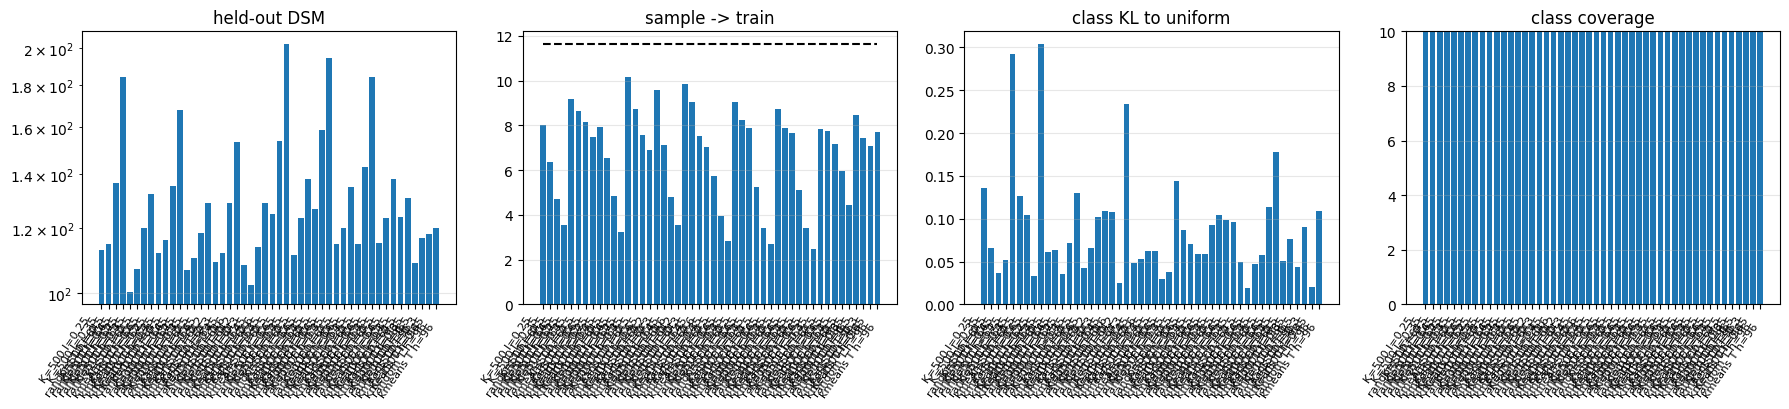

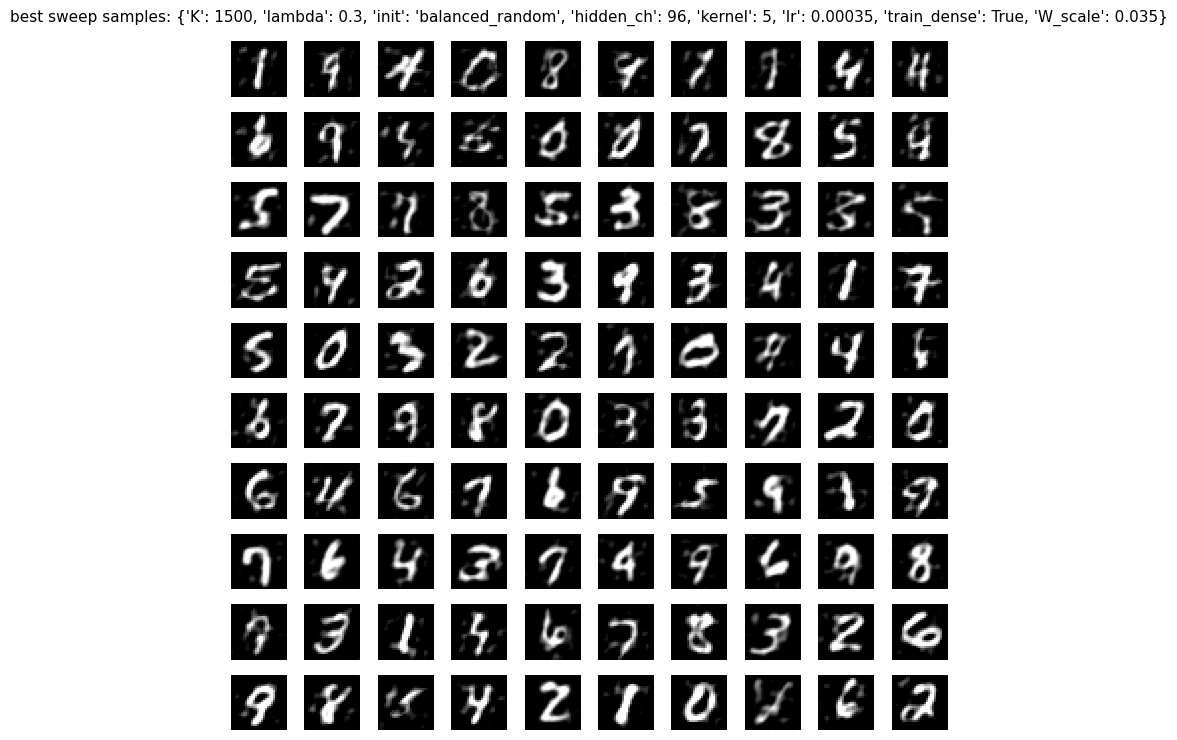

In [13]:
labels = [f"K={r['cfg']['K']} l={r['cfg']['lambda']}\n{r['cfg']['init'][9:]} {'T' if r['cfg'].get('train_dense', True) else 'F'} h={r['cfg']['hidden_ch']}" for r in sweep_results]
xs = np.arange(len(sweep_results))
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
axes[0].bar(xs, [r["val_loss"] for r in sweep_results]); axes[0].set_yscale("log"); axes[0].set_title("held-out DSM")
axes[1].bar(xs, [r["median_sample_to_train"] for r in sweep_results]); axes[1].plot(xs, [r["median_train_to_train"] for r in sweep_results], "k--"); axes[1].set_title("sample -> train")
axes[2].bar(xs, [r["class_kl"] for r in sweep_results]); axes[2].set_title("class KL to uniform")
axes[3].bar(xs, [r["coverage"] for r in sweep_results]); axes[3].set_ylim(0, 10); axes[3].set_title("class coverage")
for ax in axes:
    ax.set_xticks(xs)
    ax.set_xticklabels(labels, rotation=55, ha="right", fontsize=8)
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()
show_image_grid(best["samples"], f"best sweep samples: {best['cfg']}")

## Final Retrain

In [14]:
final_results = []
for candidate_name, row in final_candidates:
    final_cfg = row["cfg"]
    print("\nfinal candidate:", candidate_name, final_cfg)
    key, sub = random.split(key)
    final_params_seq, final_losses, final_wall, key = train_schedule(sub, train_images, final_cfg, TIME_GRID_FINAL, STEPS_PER_TIME_FINAL, BATCH_SIZE, verbose=True)
    final_stacked = stack_params(final_params_seq)
    key, sub = random.split(key)
    final_val = validation_loss(final_stacked, sub, valid_images, TIME_GRID_FINAL, min(128, BATCH_SIZE), final_cfg["lambda"])
    key, sub = random.split(key)
    final_samples, key = reverse_sample(sub, final_stacked, TIME_GRID_FINAL, final_cfg["lambda"], N_SAMPLES, N_REVERSE_STEPS)
    final_diag = diagnostics(final_samples, train_images, train_labels, prototypes_flat=np.asarray(final_params_seq[0]["dense"]["c"]))
    final_results.append({
        "name": candidate_name,
        "cfg": final_cfg,
        "params_seq": final_params_seq,
        "losses": final_losses,
        "stacked": final_stacked,
        "samples": final_samples,
        "val_loss": float(final_val),
        "wall": final_wall,
        **final_diag,
    })
    print(f"final {candidate_name} wall={final_wall:.1f}s val={float(final_val):.3f}")
    print("final diagnostics:", final_diag)

final_control = float(final_results[0]["median_train_to_train"])
def final_rank_score(r):
    st = r["median_sample_to_train"] / final_control
    ss = r["median_sample_to_sample"] / final_control
    return r["class_kl"] + 2.0 * max(0.0, 0.35 - st) ** 2 + max(0.0, 0.45 - ss) ** 2 + 0.001 * r["val_loss"]
primary_final = min(final_results, key=final_rank_score)
print("\nprimary final:", primary_final["name"], primary_final["cfg"], {k: primary_final[k] for k in ["val_loss", "median_sample_to_train", "median_sample_to_sample", "coverage", "class_kl", "counts"]})


final candidate: best_quality {'K': 1500, 'lambda': 0.3, 'init': 'balanced_random', 'hidden_ch': 96, 'kernel': 5, 'lr': 0.00035, 'train_dense': True, 'W_scale': 0.035}


K=1500 l=0.3 h=96 k=5 balanced_random trainDense | t=3.000 sigma2=0.9975 loss=8.5232e-01


K=1500 l=0.3 h=96 k=5 balanced_random trainDense | t=2.676 sigma2=0.9953 loss=7.5756e-01


K=1500 l=0.3 h=96 k=5 balanced_random trainDense | t=2.351 sigma2=0.9909 loss=1.0443e+00


K=1500 l=0.3 h=96 k=5 balanced_random trainDense | t=2.027 sigma2=0.9826 loss=1.9057e+00


...

K=1500 l=0.5 h=64 k=5 balanced_random frozenDense | t=1.053 sigma2=0.8784 loss=1.0034e+01


K=1500 l=0.5 h=64 k=5 balanced_random frozenDense | t=0.729 sigma2=0.7672 loss=1.8350e+01


K=1500 l=0.5 h=64 k=5 balanced_random frozenDense | t=0.404 sigma2=0.5546 loss=4.5564e+01


K=1500 l=0.5 h=64 k=5 balanced_random frozenDense | t=0.080 sigma2=0.1479 loss=7.0656e+02


final best_frozen wall=10.9s val=91.278
final diagnostics: {'median_sample_to_train': 2.6942834854125977, 'median_train_to_train': 11.61972427368164, 'median_sample_to_sample': 12.602383613586426, 'counts': {0: 5, 1: 12, 2: 9, 3: 8, 4: 11, 5: 13, 6: 8, 7: 7, 8: 18, 9: 9}, 'coverage': 10, 'class_kl': 0.05797919452451466, 'median_sample_to_proto': 2.706167697906494}

primary final: best_frozen {'K': 1500, 'lambda': 0.5, 'init': 'balanced_random', 'hidden_ch': 64, 'kernel': 5, 'lr': 0.0005, 'train_dense': False, 'W_scale': 0.035} {'val_loss': 91.27828216552734, 'median_sample_to_train': 2.6942834854125977, 'median_sample_to_sample': 12.602383613586426, 'coverage': 10, 'class_kl': 0.05797919452451466, 'counts': {0: 5, 1: 12, 2: 9, 3: 8, 4: 11, 5: 13, 6: 8, 7: 7, 8: 18, 9: 9}}


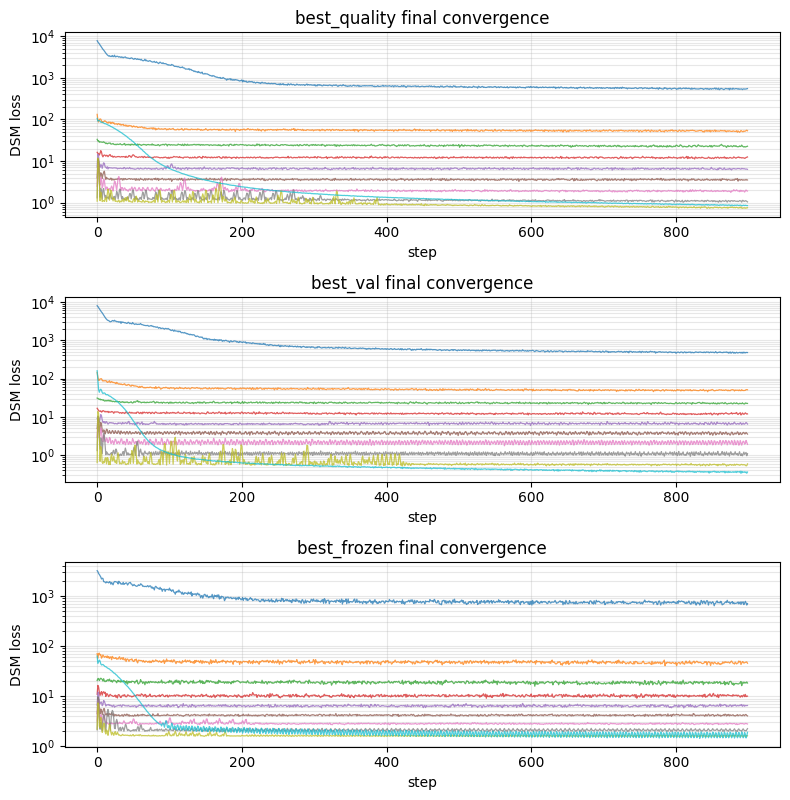

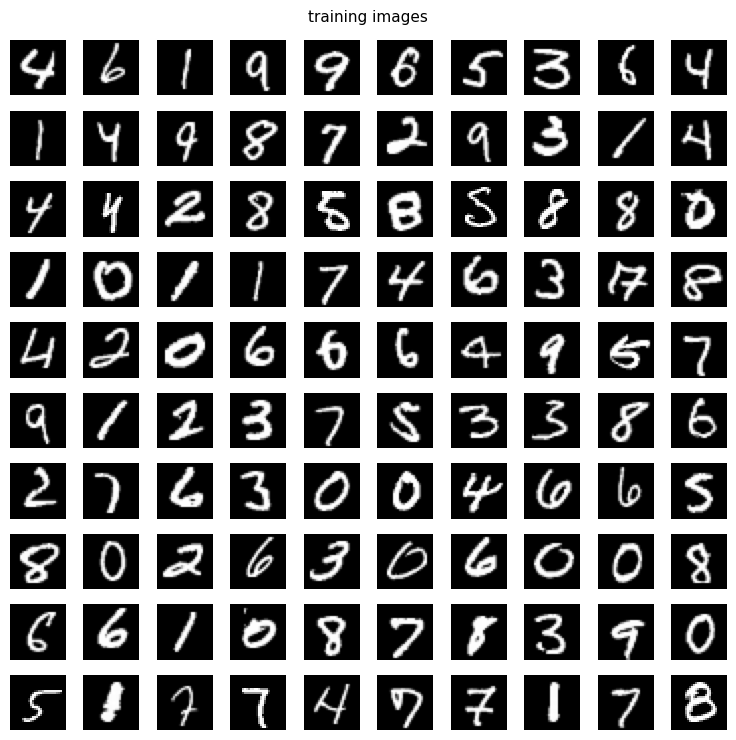

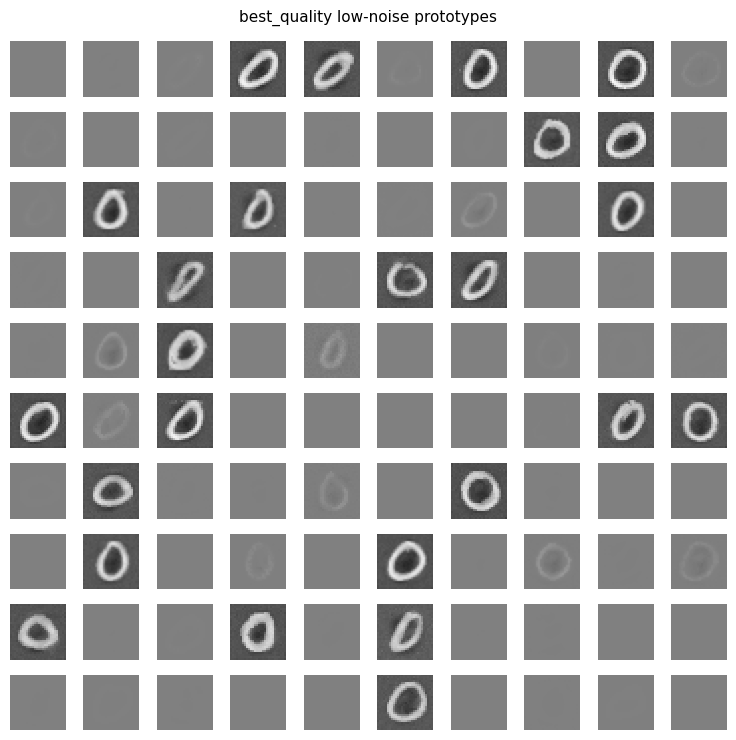

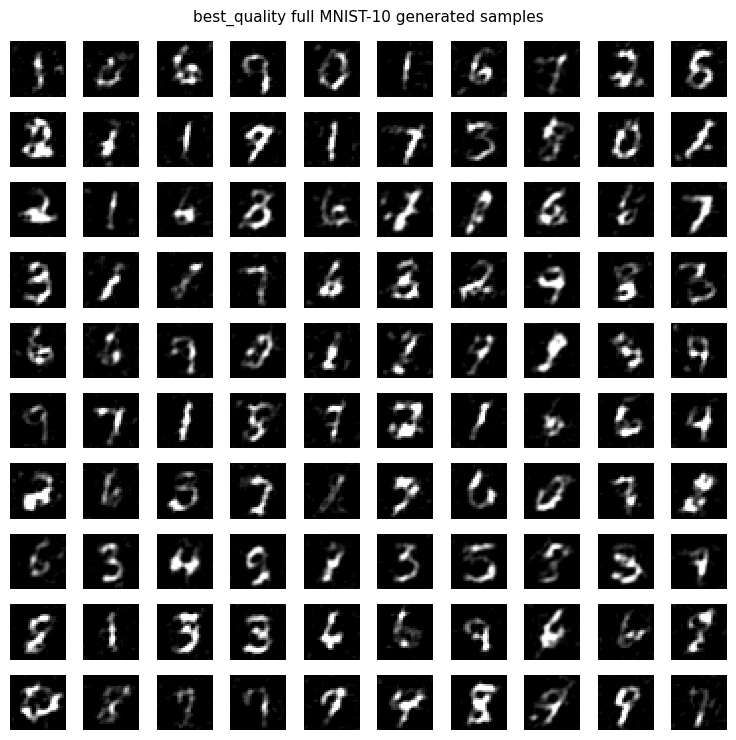

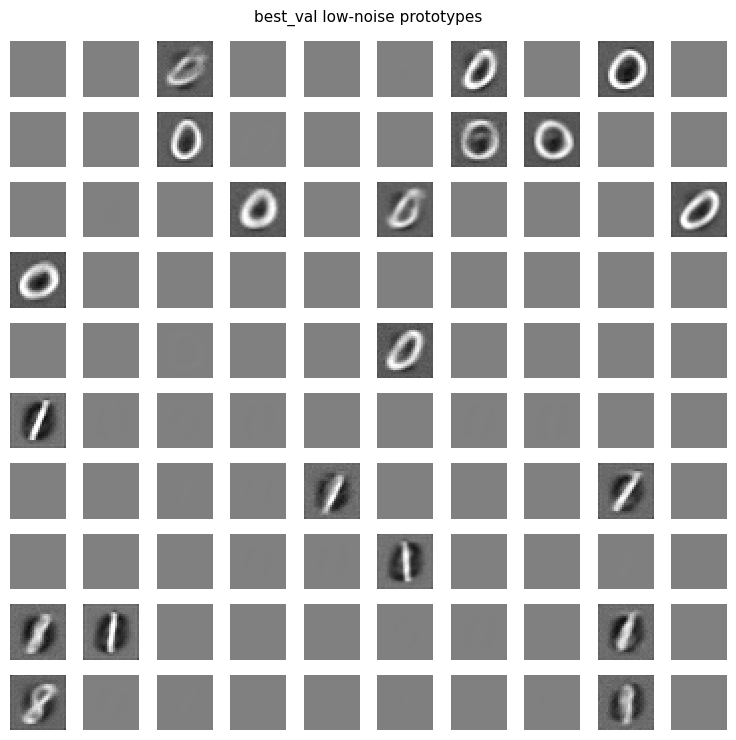

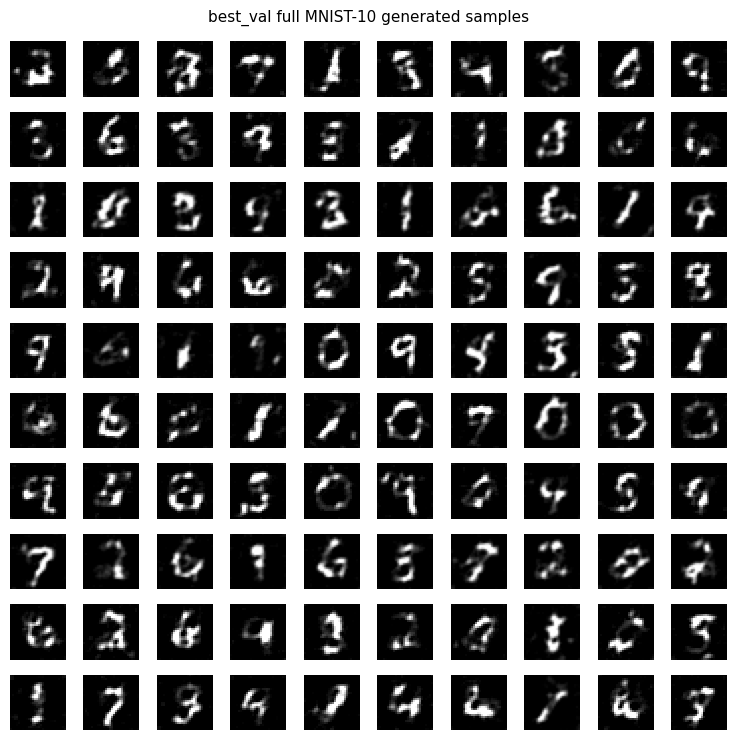

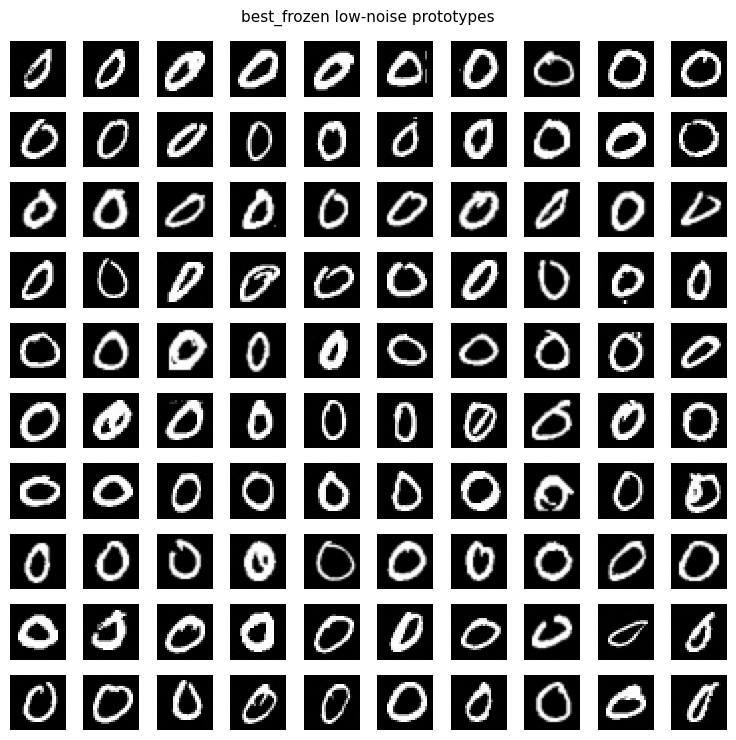

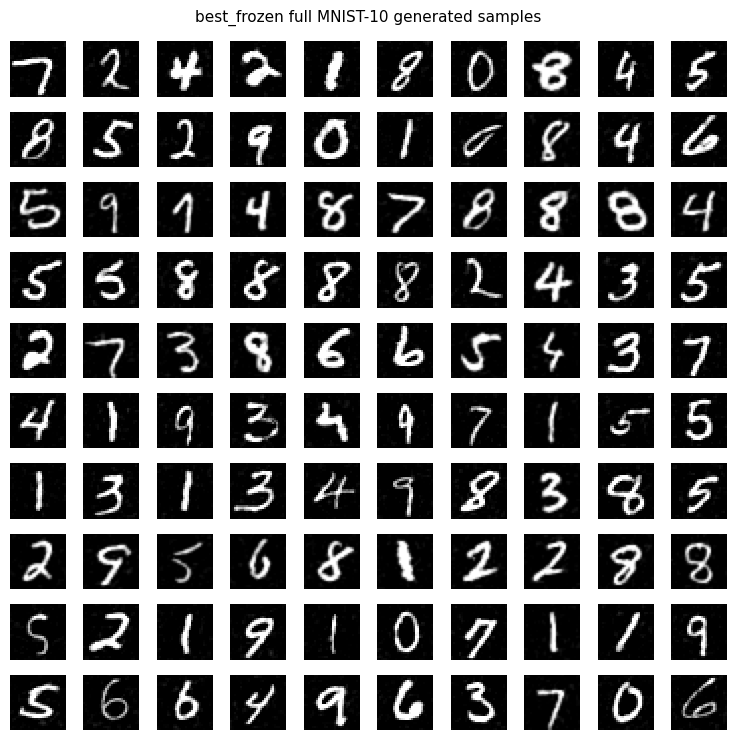

saved hybrid_mnist10_fullres_sweep_outputs.npz


In [15]:
fig, axes = plt.subplots(len(final_results), 1, figsize=(8, 2.7 * len(final_results)), squeeze=False)
for ax, result in zip(axes.ravel(), final_results):
    for idx, losses in enumerate(result["losses"]):
        ax.plot(losses, alpha=0.75, linewidth=0.9)
    ax.set_yscale("log")
    ax.set_title(f"{result['name']} final convergence")
    ax.set_xlabel("step")
    ax.set_ylabel("DSM loss")
    ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

key, k_view = random.split(key)
idx = random.randint(k_view, (N_SAMPLES,), minval=0, maxval=train_images.shape[0])
show_image_grid(train_images[idx], "training images")
for result in final_results:
    protos = np.asarray(result["params_seq"][0]["dense"]["c"]).reshape((-1, IMG_SIDE, IMG_SIDE, 1))
    show_image_grid(protos, f"{result['name']} low-noise prototypes", n_show=min(100, protos.shape[0]))
    show_image_grid(result["samples"], f"{result['name']} full MNIST-10 generated samples")

np.savez(
    "hybrid_mnist10_fullres_sweep_outputs.npz",
    train_preview=np.asarray(train_images[idx]),
    primary_samples=np.asarray(primary_final["samples"]),
    primary_prototypes=np.asarray(primary_final["params_seq"][0]["dense"]["c"]),
)
print("saved hybrid_mnist10_fullres_sweep_outputs.npz")

## Reading The Result

Good all-digit behavior should have:

- class coverage close to 10;
- class KL near 0;
- sample-to-train near, but not far below, the train-control distance;
- sample-to-sample not near zero;
- images that are legible digits rather than local stroke garbage.

If the best config still fails visually, the next step is not just larger `K`: use a time-dependent `lambda(t)` or a second global/coarse-scale latent layer.